> 🎯 **Projet : SmartFarm – Prédire la production d’œufs et détecter les lots à risque**

---

## 1. Idée générale du projet

Tu as (ou tu auras) plusieurs lots de poules pondeuses.
Pour chaque lot, chaque semaine, tu enregistres :

* ce que tu leur donnes (aliment),
* leurs conditions (température, mortalité, etc.),
* et le résultat (nombre d’œufs).

Avec ça tu vas :

1. **Régression 1** : prédire le nombre d’œufs/hen/jour pour un lot donné.
2. **Régression 2 (option)** : prédire la consommation d’aliment par poule.
3. **Classification binaire** : prédire si un lot sera **sous-performant** (à surveiller).
4. **Classification multi-classes** : classer un lot en **faible / moyen / très productif**.
5. Utiliser :

   * **régression linéaire** (simple + multiple),
   * **polynomial features**,
   * **gradient descent + feature scaling**,
   * **normal equation**,
   * **logistic regression**,
   * **regularization** (pour éviter l’overfitting).

Tu peux le faire :

* d’abord **en “from scratch”** avec NumPy comme dans le cours,
* puis **avec scikit-learn** pour un rendu plus “pro” pour ton CV.

---

## 2. Design du dataset (sur ta ferme)

👉 **Une ligne = un lot de poules sur une semaine**

### 2.1. Features proposées

| Colonne                | Type  | Description                                                           |
| ---------------------- | ----- | --------------------------------------------------------------------- |
| `week_id`              | int   | Identifiant de la semaine (1, 2, 3, …)                                |
| `flock_id`             | int   | Identifiant du lot                                                    |
| `age_weeks`            | float | Âge moyen des poules (en semaines)                                    |
| `num_hens`             | int   | Nombre de poules dans le lot                                          |
| `feed_g_per_hen_day`   | float | Quantité moyenne de nourriture par poule (g/jour)                     |
| `feed_type`            | cat   | Type d’aliment (ex: 0 = maïs seul, 1 = maïs+soja, 2 = maïs+son+soja…) |
| `avg_temp`             | float | Température moyenne (°C) dans le poulailler cette semaine             |
| `mortality_rate`       | float | % de mortalité cette semaine                                          |
| `avg_weight_kg`        | float | Poids moyen d’une poule dans le lot                                   |
| `lights_hours_per_day` | float | Nombre d’heures de lumière/jour                                       |
| `disease_outbreak`     | 0/1   | 1 si suspicion maladie cette semaine, sinon 0                         |


In [961]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sympy.abc import y

from data.genrate_data import generate_poultry_data

In [962]:


data = generate_poultry_data()
data_size = float(data.shape[0])
seventy_pct = int(data_size * 0.7)
training_sets = data.head(seventy_pct)
testing_sets = data.head(int(data_size - seventy_pct))

X_train = training_sets['age_weeks'].values.astype(float)
Y_train = training_sets['eggs_per_hen_day'].values.astype(float)

x_test = testing_sets['age_weeks'].values.astype(float)
y_test = testing_sets['eggs_per_hen_day'].values.astype(float)

f_w_b = W*X+b

In [963]:
def model(x, w, b):
    return np.dot(w, x) + b

In [964]:
def cost_function(x, w, b, y):
    """
    j_w_b = (1/2m)*sum(f_w_b-y)^2
    :return:
    """
    m = x.shape[0]
    square_error = 0
    for i in range(m):
        f_w_b = w * x[i] + b
        square_error += (f_w_b - y[i]) ** 2
    j_w_b = square_error / (2 * m)
    return j_w_b


In [965]:
# def cost_function_vector(x, w, b, y):
#     m = x.shape[0]
#     cost = np.sum((model(w,b)-y)**2)
#     cost = cost/(2*m)
#     return cost
#     return cost

In [966]:
# cost_function_vector(x_train, 0.9, 0.5, y_train)

In [967]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_w = 0
    dj_b = 0
    for i in range(m):
        f_w_b = w * x[i] + b
        dj_w += (f_w_b - y[i]) * x[i]
        dj_b += (f_w_b - y[i])
    dj_w = dj_w / m
    dj_b = dj_b / m
    return dj_w, dj_b


In [968]:
compute_gradient(X_train, Y_train, 0.9, 0.5)

(1523.7218809523808, 35.224880952380964)

In [969]:
# def compute_gradient_vector(x, y, w, b):
#     m = x.shape[0]
#     f_w_b = np.dot(w, x)+b
#     dj_w = np.sum((f_w_b-y)*x)/m
#     dj_b = np.sum(f_w_b-y)/m
#     return dj_w, dj_b


In [970]:
# compute_gradient_vector(x_train, y_train, 0.9, 0.5)

In [971]:
def descent_gradient(x, y, learning_rate, iterations):
    w = 0
    b = 0
    j_history = []
    p_history = []
    for i in range(iterations):
        dj_w, dj_b = compute_gradient(x, y, w, b)
        w -= learning_rate * dj_w
        b -= learning_rate * dj_b
        j_history.append(cost_function(x, w, b, y))
        p_history.append([w, b])
    return j_history, p_history, w, b


In [972]:
X_mean = np.mean(X_train)
X_std = np.std(X_train)
X_lin_norm = (X_train - X_mean) / X_std

j_history_out, p_history_out, w_j, b_j = descent_gradient(X_lin_norm, Y_train, 0.09, 80)

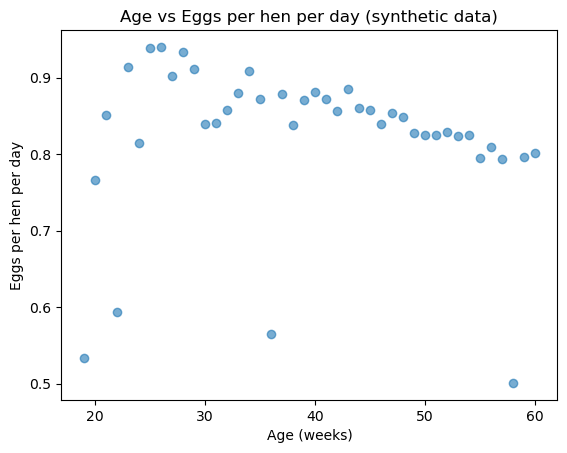

In [973]:

plt.scatter(X_train, Y_train, alpha=0.6)
plt.xlabel("Age (weeks)")
plt.ylabel("Eggs per hen per day")
plt.title("Age vs Eggs per hen per day (synthetic data)")
plt.show()

Learned parameters (linear regression):
w = -0.009407125603574252
b = 0.8246827046338663


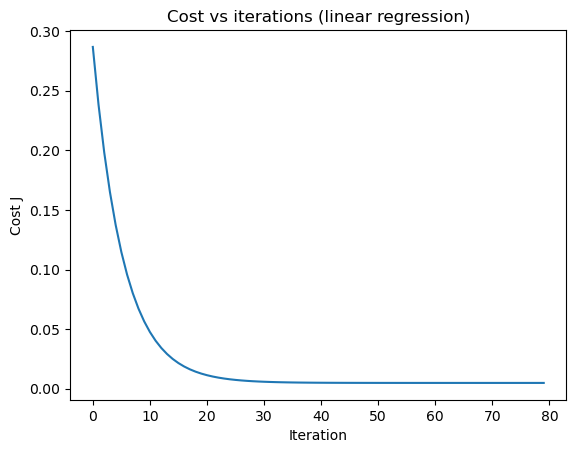

In [974]:
print("Learned parameters (linear regression):")
print("w =", w_j)
print("b =", b_j)

# Plot cost over iterations
plt.plot(j_history_out)
plt.xlabel("Iteration")
plt.ylabel("Cost J")
plt.title("Cost vs iterations (linear regression)")
plt.show()

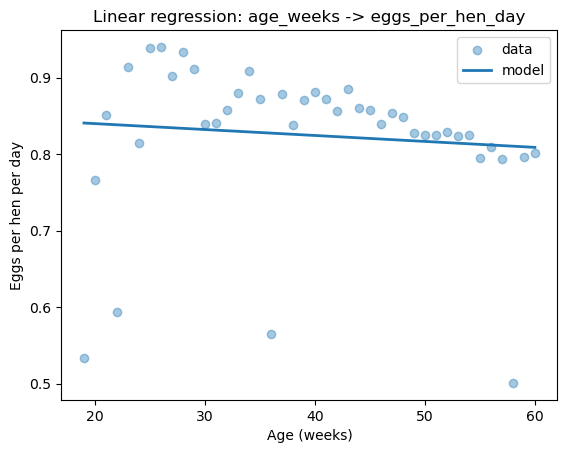

In [975]:
# Plot regression line vs data (convert normalized x back to original scale for plotting)
x_plot = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
x_plot_norm = (x_plot - X_mean) / X_std
y_plot = x_plot_norm * w_j + b_j
plt.scatter(X_train, Y_train, alpha=0.4, label="data")
plt.plot(x_plot, y_plot, label="model", linewidth=2)
plt.xlabel("Age (weeks)")
plt.ylabel("Eggs per hen per day")
plt.title("Linear regression: age_weeks -> eggs_per_hen_day")
plt.legend()
plt.show()

In [976]:
def feature_matrix():
    age_weeks = data['age_weeks'].astype(float)
    feed_g_per_hen_day = data['feed_g_per_hen_day']
    avg_temp = data['avg_temp']
    mortality_rate = data['mortality_rate']
    avg_weight_kg = data['avg_weight_kg']
    lights_hours_per_day = data['lights_hours_per_day']
    feed_type = data['feed_type']
    return np.column_stack([
        age_weeks,
        feed_g_per_hen_day,
        avg_temp,
        mortality_rate,
        avg_weight_kg,
        lights_hours_per_day,
        feed_type
    ])

In [977]:
X_train_two = feature_matrix()
Y_train_two = data['eggs_per_hen_day']
w_init = np.zeros(X_train_two.shape[-1])


In [978]:
X_mean_two = np.mean(X_train_two)
X_std_two = np.std(X_train_two)
X_lin_norm_two = (X_train_two - X_mean_two) / X_std_two

In [979]:
def predict(x, w, b):
    return np.dot(w, x) + b

In [980]:
def cost_function_vector(X, w, b, y):
    m = X.shape[0]
    y_pred_ = X @ w + b
    errors = y_pred_ - y
    cost = np.sum(errors ** 2) / (2 * m)
    return cost

In [981]:
cost_function_vector(X_lin_norm_two, w_init, 0.5, Y_train_two)

0.0494721

In [982]:
def compute_gradient_multi(X, Y, w, b):
    m, n = X.shape
    y_pred_ = X @ w + b
    errors = y_pred_ - Y

    dj_w = (X.T @ errors) / m      # gradient vecteur
    dj_b = np.sum(errors) / m      # gradient scalaire

    return dj_w, dj_b

In [983]:
def descent_gradient_multi(X_, Y_, learning_rate, iterations):
    m, n = X_.shape
    w_init_two = np.zeros(n)
    b_init_two = 0
    j_history = []
    p_history = []
    for i in range(iterations):
        dj_w, dj_b = compute_gradient_multi(X_, Y_, w_init_two, b_init_two)
        w_init_two -= learning_rate * dj_w
        b_init_two -= learning_rate * dj_b
        j_history.append(cost_function_vector(X_, w_init_two, b_init_two, Y_))
        p_history.append([w_init_two, b_init_two])
    return j_history, p_history, w_init_two, b_init_two

In [984]:
j_history, p_history, w_final, b_final = descent_gradient_multi(
    X_lin_norm_two,
    Y_train_two,
    learning_rate=0.05,
    iterations=250
)

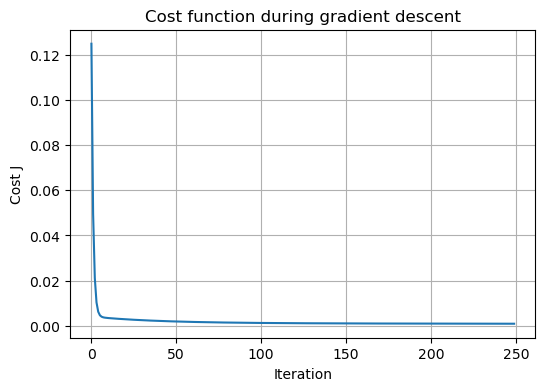

In [985]:

plt.figure(figsize=(6, 4))
plt.plot(j_history)
plt.xlabel("Iteration")
plt.ylabel("Cost J")
plt.title("Cost function during gradient descent")
plt.grid(True)
plt.show()

In [986]:
y_pred = X_lin_norm_two @ w_final + b_final

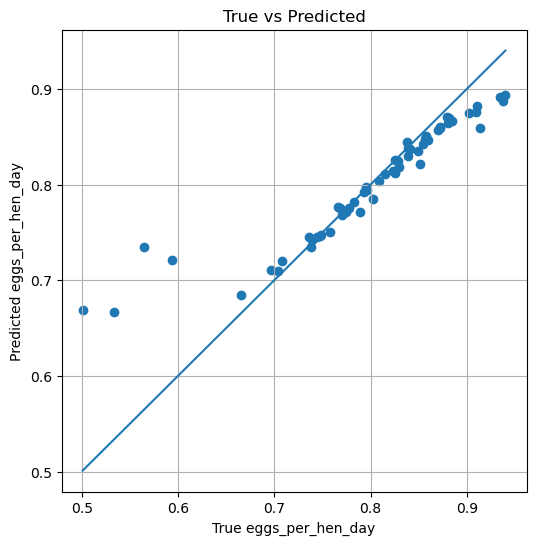

In [987]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_train_two, y_pred)
plt.xlabel("True eggs_per_hen_day")
plt.ylabel("Predicted eggs_per_hen_day")
plt.title("True vs Predicted")
# ligne y = x pour voir si on est proche de la diagonale
min_val = min(Y_train_two.min(), y_pred.min())
max_val = max(Y_train_two.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.grid(True)
plt.show()

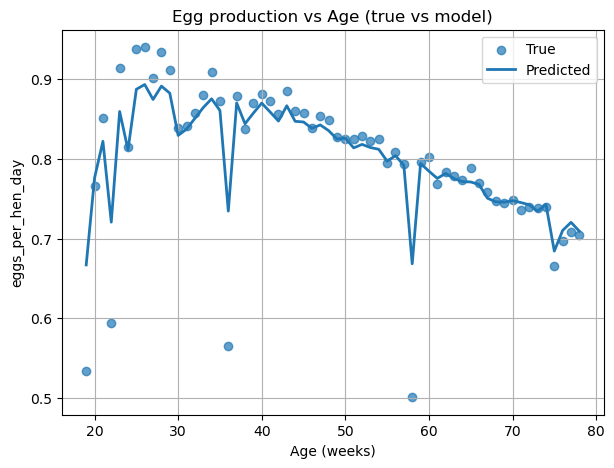

In [988]:
age = data['age_weeks'].astype(float).values

# Pour avoir une belle courbe, on tri par âge
idx_sorted = np.argsort(age)
age_sorted = age[idx_sorted]
X_sorted = X_train_two[idx_sorted]
X_sorted_norm = (X_sorted - X_mean_two) / X_std_two
y_sorted_pred = X_sorted_norm @ w_final + b_final
y_sorted_true = Y_train_two[idx_sorted]

plt.figure(figsize=(7, 5))
plt.scatter(age_sorted, y_sorted_true, label="True", alpha=0.7)
plt.plot(age_sorted, y_sorted_pred, label="Predicted", linewidth=2)
plt.xlabel("Age (weeks)")
plt.ylabel("eggs_per_hen_day")
plt.title("Egg production vs Age (true vs model)")
plt.legend()
plt.grid(True)
plt.show()
